In [1]:
import pandas as pd
from pathlib import Path

# ============================================================
# PULIZIA COLONNINE PUBBLICHE (PUN) + MAPPATURA OPERATORI + MAPPA
# ============================================================
# Fonte: Piattaforma Unica Nazionale (PUN, MASE/GSE), scaricata
# con scarica_colonnine_pun.py (PROJECT WORK/).

CARTELLA = Path(".")
df = pd.read_csv(CARTELLA / "pun_colonnine.csv")

print(f"Righe totali: {len(df):,}")
df["status"].value_counts()

Righe totali: 73,607


/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


status
AVAILABLE      53126
OUTOFORDER     10486
CHARGING        5569
UNKNOWN         2027
REMOVED          920
BLOCKED          839
INOPERATIVE      599
RESERVED          34
PLANNED            7
Name: count, dtype: int64

In [2]:
# Deduplicazione righe esattamente identiche.
# Il file grezzo contiene righe ripetute (stesso evse_id, status e
# coordinate) verosimilmente per doppio invio nello stesso scarico
# della piattaforma PUN. Non e' un problema di posizione (le
# coordinate coincidono sempre in questi casi), ma va rimosso prima
# di ogni conteggio per non gonfiare artificialmente il numero di
# colonnine.
righe_prima = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Righe duplicate esatte rimosse: {righe_prima - len(df):,}")
print(f"Righe rimaste: {len(df):,}")

Righe duplicate esatte rimosse: 15
Righe rimaste: 73,592


In [3]:
# Quali stati rappresentano una colonnina che FISICAMENTE ESISTE
# (anche se non disponibile in questo momento) e quali invece una
# colonnina che non esiste più o non esiste ancora:
#
#   AVAILABLE, CHARGING, RESERVED    -> chiaramente attiva/esistente
#   OUTOFORDER, INOPERATIVE, BLOCKED -> stato temporaneo (guasto,
#       manutenzione, blocco d'accesso): la colonnina esiste
#       fisicamente e con ogni probabilità tornerà disponibile
#   UNKNOWN -> stato non pervenuto dal fornitore in questo momento,
#       non un'informazione sulla colonnina in sé: la teniamo dando
#       il beneficio del dubbio (probabile problema di feed dati,
#       non di rimozione fisica della colonnina)
#   REMOVED -> dismessa, non esiste più: ESCLUSA
#   PLANNED -> non ancora installata, non esiste ancora: ESCLUSA
#
# Escludiamo quindi solo REMOVED e PLANNED: sono gli unici due stati
# che NON corrispondono a una colonnina fisicamente presente e
# potenzialmente utilizzabile, coerentemente con il criterio
# discusso (mantenere anche gli stati transitori tipo manutenzione
# o carica in corso).
STATI_DA_ESCLUDERE = ["REMOVED", "PLANNED"]

colonnine = df[~df["status"].isin(STATI_DA_ESCLUDERE)].copy()

print(f"Righe totali: {len(df):,}")
print(f"Escluse ({', '.join(STATI_DA_ESCLUDERE)}): {len(df) - len(colonnine):,}")
print(f"Colonnine tenute: {len(colonnine):,}")

Righe totali: 73,592
Escluse (REMOVED, PLANNED): 927
Colonnine tenute: 72,665


In [4]:
# Deduplicazione di evse_id ripetuti con STATUS diverso tra le due
# occorrenze (32 casi, es. la stessa colonnina compare una volta
# come "CHARGING" e una volta come "AVAILABLE"). Non e' un problema
# di posizione: in tutti i 32 casi lat/lon/operatore coincidono
# perfettamente tra le due righe, cambia solo lo stato. La spiegazione
# piu' plausibile e' che il file grezzo unisca due scarichi della
# piattaforma PUN fatti in momenti diversi (due "fotografie" dello
# stesso punto fisico), senza una colonna di timestamp che permetta
# di capire quale delle due sia la più recente.
#
# Dato che l'analisi a valle (deserti di ricarica) si basa sulla
# PRESENZA fisica della colonnina e non sul suo stato istantaneo,
# teniamo una sola riga per evse_id: la scelta tra le due non incide
# sulla posizione ne' sull'azienda, quindi si tiene semplicemente la
# prima occorrenza nel file.
n_duplicati_evse = colonnine["evse_id"].duplicated().sum()
colonnine = colonnine.drop_duplicates(subset="evse_id", keep="first").reset_index(drop=True)
print(f"Evse_id duplicati (stesso ID, status diverso) risolti: {n_duplicati_evse}")
print(f"Colonnine rimaste: {len(colonnine):,}")

Evse_id duplicati (stesso ID, status diverso) risolti: 17
Colonnine rimaste: 72,648


In [5]:
# Estrazione del codice operatore dall'evse_id. Formato osservato:
# dopo il prefisso "IT" (a volte seguito da un "*" separatore, a
# volte no), i 3 caratteri successivi sono il codice CPO, es.
#   "IT*ENX*ESN2403150193*2" -> "ENX"
#   "ITGESE795962332"        -> "GES"
# Non copre alla perfezione tutti i 130 codici distinti presenti nel
# dataset: una piccola coda (~1-2% delle righe) ha evse_id con un
# formato completamente diverso (senza prefisso "IT", schemi ad hoc)
# e produce codici spuri: verranno gestiti come "non mappati" nella
# cella successiva, non nascosti.
def estrai_codice_operatore(evse_id):
    s = str(evse_id)[2:]  # rimuove il prefisso "IT"
    if s.startswith("*"):
        s = s[1:]
    return s[:3]

colonnine["operatore_codice"] = colonnine["evse_id"].apply(estrai_codice_operatore)
print(f"Codici operatore distinti: {colonnine['operatore_codice'].nunique()}")
colonnine["operatore_codice"].value_counts().head(15)

Codici operatore distinti: 129


operatore_codice
ENX    21378
PLN    19664
A2M     3156
GES     2999
TSL     2397
ATE     1938
EWI     1650
ACE     1634
DUF     1360
ASM     1344
AM2     1332
ESH      894
F2X      845
EMO      817
HRA      813
Name: count, dtype: int64

In [6]:
import json

# Elenco ufficiale degli operatori accreditati sulla PUN (sigla ->
# ragione sociale), scaricato con scarica_operatori_pun.py
# dall'endpoint /v1/operators della stessa piattaforma (trovato per
# tentativi, non documentato pubblicamente).
with open(CARTELLA / "operatori_pun.json", encoding="utf-8") as f:
    OPERATORI_UFFICIALI = json.load(f)

# Eccezione dichiarata: "PLN" non compare nel registro ufficiale, ma
# copre da sola quasi un quarto delle colonnine del dataset (circa
# 19.700 punti). Il registro ufficiale include invece "BEC" ->
# "Plenitude On The Road S.r.l." con solo 30 punti. Il volume di
# PLN (coerente con gli oltre 20.000 punti dichiarati da Be Charge/
# Plenitude a luglio 2024 secondo fonti di settore) e la posizione
# di mercato nota di Be Charge/Plenitude come secondo operatore
# italiano dopo Enel X rendono plausibile che PLN sia un codice
# legacy della stessa azienda, non ancora aggiornato nel registro.
# La trattiamo come un'inferenza dichiarata, non una conferma
# ufficiale.
MAPPATURA_MANUALE = {
    "PLN": "Plenitude / Be Charge (inferito, non nel registro ufficiale)",
}

def mappa_azienda(codice):
    if codice in OPERATORI_UFFICIALI:
        return OPERATORI_UFFICIALI[codice]
    if codice in MAPPATURA_MANUALE:
        return MAPPATURA_MANUALE[codice]
    return "Non mappato ufficialmente"

colonnine["azienda"] = colonnine["operatore_codice"].apply(mappa_azienda)

quota_non_mappata = (colonnine["azienda"] == "Non mappato ufficialmente").mean()
print(f"Quota di colonnine non mappate a un'azienda: {quota_non_mappata:.1%}")

Quota di colonnine non mappate a un'azienda: 7.5%


In [7]:
# ------------------------------------------------------------
# CONTROLLO QUALITA': coordinate "mega-hub"
# ------------------------------------------------------------
# 72mila+ evse_id insistono su appena ~30mila coordinate distinte
# (mediana 2 evse per punto, normale: piu' colonnine nello stesso
# parcheggio). Ma la coda della distribuzione e' anomala: alcune
# coordinate concentrano da 56 fino a 495 evse_id sullo stesso
# punto esatto, quasi tutte sotto il codice PLN (Plenitude/Be
# Charge, gia' segnalato come inferito e non nel registro
# ufficiale).
#
# Verifica fatta con reverse geocoding (Nominatim/OSM) su tutti i 13
# casi: risultano indirizzi reali e specifici (via, civico, area),
# non centroidi di comune o altri placeholder da geocoding fallito,
# es.:
#   45.951820, 12.695877 (495 evse) -> Via Musile, Case Levade (PN)
#   45.642267, 12.596594 (317 evse) -> Via dei Laghi, San Dona' di
#                                      Piave (VE), gia' taggato su
#                                      OSM come stazione di ricarica
#   40.857961, 14.279002 (202 evse) -> Centro Direzionale, Napoli
#
# Verifica aggiuntiva fatta direttamente sul campo (controllo umano,
# non solo reverse geocoding): confermato che questi mega-hub sono
# siti reali, non un artefatto di raccolta dati. Nessuna riga viene
# quindi tagliata o modificata: la colonna n_evse_stesso_punto resta
# solo a scopo informativo, cosi' chi fa analisi di densita' spaziale
# sa che questi punti concentrano legittimamente molte colonnine e
# puo' decidere se aggregarli per sito invece che contarli uno per
# uno.
colonnine["n_evse_stesso_punto"] = (
    colonnine.groupby(["latitude", "longitude"])["evse_id"].transform("count")
)

SOGLIA_MEGA_HUB = 50
mega_hub = (
    colonnine.loc[colonnine["n_evse_stesso_punto"] > SOGLIA_MEGA_HUB, ["latitude", "longitude", "n_evse_stesso_punto"]]
    .drop_duplicates()
    .sort_values("n_evse_stesso_punto", ascending=False)
)
print(f"Coordinate con oltre {SOGLIA_MEGA_HUB} evse_id sullo stesso punto: {len(mega_hub)}")
print(f"Evse_id coinvolti: {mega_hub['n_evse_stesso_punto'].sum():,} ({mega_hub['n_evse_stesso_punto'].sum() / len(colonnine):.1%} del totale)")
mega_hub

Coordinate con oltre 50 evse_id sullo stesso punto: 13
Evse_id coinvolti: 2,367 (3.3% del totale)


,latitude,longitude,n_evse_stesso_punto
5,45.951820,12.695877,495
218,45.642267,12.596594,317
75,46.089355,13.144679,273
1379,40.857961,14.279002,202
854,40.858953,14.284832,194
2291,40.854102,14.225997,178
621,40.856454,14.278804,144
964,40.856623,14.280568,135
3221,40.857312,14.283336,112
615,45.591138,9.312000,104


azienda
ENEL X WAY ITALIA SRL                                           21378
Plenitude / Be Charge (inferito, non nel registro ufficiale)    19664
Non mappato ufficialmente                                        5431
A2A E.MOBILITY S.R.L.                                            3156
Go Electric Stations SRLS                                        2999
Tesla Italia Srl.                                                2397
Atlante S.r.l                                                    1938
EWIVA SRL                                                        1650
ACEA ENERGIA                                                     1634
DUFERCO MOBILITY SRL                                             1360
NEOGY SRL                                                        1344
E-Shore s.r.l.                                                    894
Free To X S.p.A.                                                  845
EMOBITALY S.r.l.                                                  817
Edison Next 

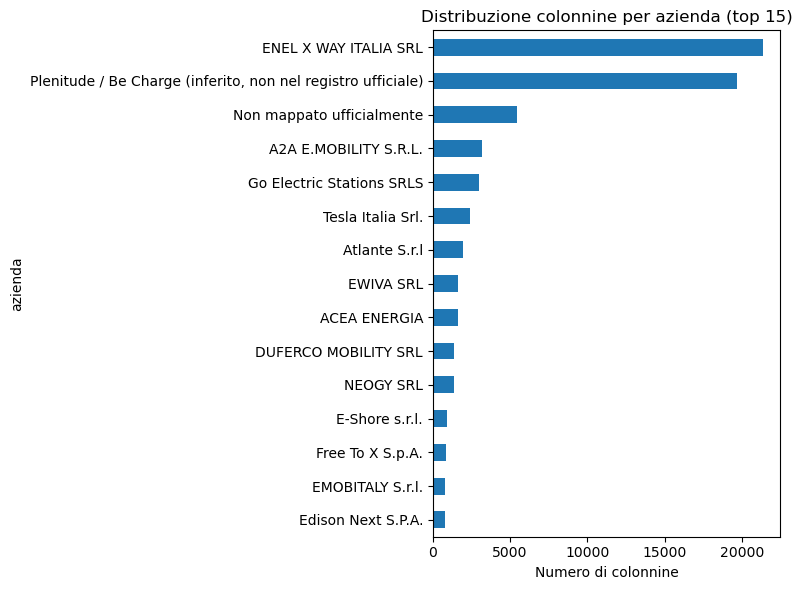

In [8]:
import matplotlib.pyplot as plt

distribuzione_aziende = colonnine["azienda"].value_counts()
print(distribuzione_aziende.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
distribuzione_aziende.head(15).sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("Numero di colonnine")
ax.set_title("Distribuzione colonnine per azienda (top 15)")
plt.tight_layout()
plt.show()

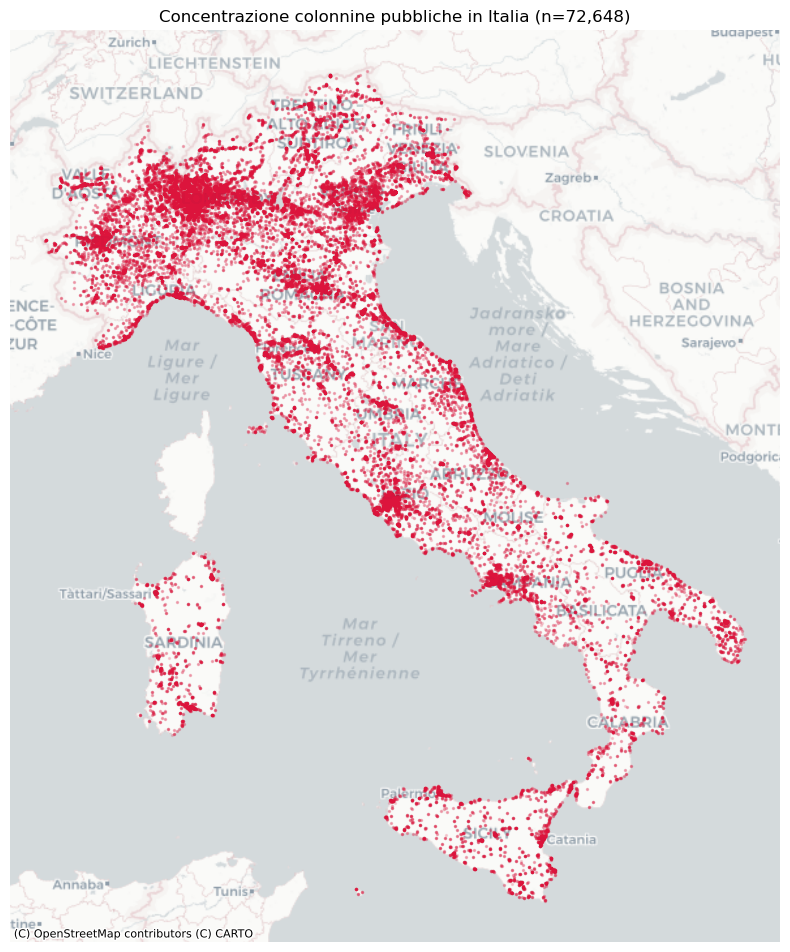

In [9]:
import geopandas as gpd
import contextily as cx

# Mappa di concentrazione: punti piccoli e semi-trasparenti, cosi'
# le zone con piu' colonnine si vedono per sovrapposizione (piu'
# scuro = piu' denso), senza dover aggregare in una griglia.
gdf = gpd.GeoDataFrame(
    colonnine,
    geometry=gpd.points_from_xy(colonnine["longitude"], colonnine["latitude"]),
    crs="EPSG:4326",
).to_crs(epsg=3857)  # Web Mercator, richiesto da contextily per le tile

fig, ax = plt.subplots(figsize=(8, 10))
gdf.plot(ax=ax, markersize=2, alpha=0.15, color="crimson")
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.set_title(f"Concentrazione colonnine pubbliche in Italia (n={len(gdf):,})")
plt.tight_layout()
plt.savefig("mappa_concentrazione_colonnine.png", dpi=150)
plt.show()

In [10]:
# File finale (colonnine attive, con azienda mappata) pronto per la
# distribuzione/join spaziale con le sezioni di censimento.
OUTPUT_CSV = "pun_colonnine_pulito.csv"
colonne_output = [
    "evse_id", "status", "latitude", "longitude", "operatore_codice", "azienda",
    "n_evse_stesso_punto",
]
colonnine[colonne_output].to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"Salvato: {OUTPUT_CSV} ({len(colonnine):,} righe)")

Salvato: pun_colonnine_pulito.csv (72,648 righe)
